In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import seaborn as sns


In [32]:

import glob
import pandas as pd
import re

# Busca todos los archivos
files = glob.glob(r"DataSets/MHEALTHDATASET/mHealth_subject*.log")

dfs = []

for file in files:
    
    # Extraer número de sujeto desde el nombre del archivo
    subject_id = int(re.search(r"subject(\d+)", file).group(1))
    
    # Leer archivo
    df = pd.read_csv(file, sep='\t', header=None)
    
    # Agregar columna subject_id
    df["subject_id"] = subject_id
    
    dfs.append(df)

# Unir todos
MHEALTHDATASET = pd.concat(dfs, ignore_index=True)

# Asignar nombres de columnas
MHEALTHDATASET.columns = [  
    # Chest sensor
    "chest_acc_x",
    "chest_acc_y",
    "chest_acc_z",
    "ecg_1",
    "ecg_2",

    # Left ankle
    "ankle_acc_x",
    "ankle_acc_y",
    "ankle_acc_z",
    "ankle_gyro_x",
    "ankle_gyro_y",
    "ankle_gyro_z",
    "ankle_mag_x",
    "ankle_mag_y",
    "ankle_mag_z",

    # Right lower arm
    "arm_acc_x",
    "arm_acc_y",
    "arm_acc_z",
    "arm_gyro_x",
    "arm_gyro_y",
    "arm_gyro_z",
    "arm_mag_x",
    "arm_mag_y",
    "arm_mag_z",

    # Label
    "activity_label",
    
    # Nuevo
    "subject_id"
]

pd.set_option('display.max_columns', None)


1. Para cada base de datos presenta sus dimensiones y las primeras 5 líneas.

In [33]:
MHEALTHDATASET.shape

(1215745, 25)

In [34]:
MHEALTHDATASET.head()

,chest_acc_x,chest_acc_y,chest_acc_z,ecg_1,ecg_2,ankle_acc_x,ankle_acc_y,ankle_acc_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,arm_acc_x,arm_acc_y,arm_acc_z,arm_gyro_x,arm_gyro_y,arm_gyro_z,arm_mag_x,arm_mag_y,arm_mag_z,activity_label,subject_id
0,-9.8184,0.009971,0.29563,0.004186,0.004186,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-0.370000,-0.36327,0.29963,-8.6499,-4.5781,0.187760,-0.44902,-1.0103,0.034483,-2.35000,-1.610200,-0.030899,0,1
1,-9.8489,0.524040,0.37348,0.004186,0.016745,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-0.197990,-0.18151,0.58298,-8.6275,-4.3198,0.023595,-0.44902,-1.0103,0.034483,-2.16320,-0.882540,0.326570,0,1
2,-9.6602,0.181850,0.43742,0.016745,0.037677,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-0.374170,0.18723,0.43851,-8.5055,-4.2772,0.275720,-0.44902,-1.0103,0.034483,-1.61750,-0.165620,-0.030693,0,1
3,-9.6507,0.214220,0.24033,0.079540,0.117220,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-0.017271,0.18366,0.57571,-8.6279,-4.3163,0.367520,-0.45686,-1.0082,0.025862,-1.07710,0.006945,-0.382620,0,1
4,-9.7030,0.303890,0.31156,0.221870,0.205130,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-0.374390,-0.54671,0.44586,-8.7008,-4.1459,0.407290,-0.45686,-1.0082,0.025862,-0.53684,0.175900,-1.095500,0,1


2. Identifica y elimina los datos ausentes.

In [35]:
MHEALTHDATASET.isnull().sum()

chest_acc_x       0
chest_acc_y       0
chest_acc_z       0
ecg_1             0
ecg_2             0
ankle_acc_x       0
ankle_acc_y       0
ankle_acc_z       0
ankle_gyro_x      0
ankle_gyro_y      0
ankle_gyro_z      0
ankle_mag_x       0
ankle_mag_y       0
ankle_mag_z       0
arm_acc_x         0
arm_acc_y         0
arm_acc_z         0
arm_gyro_x        0
arm_gyro_y        0
arm_gyro_z        0
arm_mag_x         0
arm_mag_y         0
arm_mag_z         0
activity_label    0
subject_id        0
dtype: int64

3. Presenta los tipos de datos de cada atributo de cada base de datos.

In [36]:
MHEALTHDATASET.dtypes

chest_acc_x       float64
chest_acc_y       float64
chest_acc_z       float64
ecg_1             float64
ecg_2             float64
ankle_acc_x       float64
ankle_acc_y       float64
ankle_acc_z       float64
ankle_gyro_x      float64
ankle_gyro_y      float64
ankle_gyro_z      float64
ankle_mag_x       float64
ankle_mag_y       float64
ankle_mag_z       float64
arm_acc_x         float64
arm_acc_y         float64
arm_acc_z         float64
arm_gyro_x        float64
arm_gyro_y        float64
arm_gyro_z        float64
arm_mag_x         float64
arm_mag_y         float64
arm_mag_z         float64
activity_label      int64
subject_id          int64
dtype: object

4. Presenta el resumen estadístico de cada uno de los atributos de cada base de datos.

In [37]:
MHEALTHDATASET.describe()

,chest_acc_x,chest_acc_y,chest_acc_z,ecg_1,ecg_2,ankle_acc_x,ankle_acc_y,ankle_acc_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,arm_acc_x,arm_acc_y,arm_acc_z,arm_gyro_x,arm_gyro_y,arm_gyro_z,arm_mag_x,arm_mag_y,arm_mag_z,activity_label,subject_id
count,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06,1.215745e+06
mean,-8.522361e+00,-2.140013e-01,-1.055950e+00,-5.122403e-03,-4.506434e-03,1.494200e+00,-9.692878e+00,-9.548056e-01,-1.598951e-03,-6.166318e-01,-1.587811e-01,4.818714e-01,-8.054014e-01,-8.566162e-01,-3.713413e+00,-5.805526e+00,2.393880e+00,-2.761061e-01,-4.664340e-01,2.666335e-01,1.702138e-01,7.144626e-01,-3.668126e-01,1.741465e+00,5.270370e+00
std,4.075293e+00,2.138954e+00,3.574163e+00,7.465971e-01,7.270395e-01,3.826485e+00,4.171303e+00,5.461803e+00,4.912172e-01,3.546406e-01,5.467979e-01,6.395764e+01,4.273642e+01,1.768224e+01,4.763586e+00,5.757639e+00,3.876503e+00,5.276888e-01,5.555510e-01,5.643804e-01,2.667617e+01,3.344453e+01,6.955069e+01,3.283679e+00,2.948526e+00
min,-2.243800e+01,-2.018800e+01,-1.840100e+01,-8.619600e+00,-8.619600e+00,-2.214600e+01,-1.961900e+01,-1.937300e+01,-2.146600e+00,-7.789900e+00,-2.626700e+00,-3.575600e+02,-3.656700e+02,-2.823900e+02,-2.236100e+01,-1.897200e+01,-1.823900e+01,-8.339200e+00,-3.570800e+00,-2.689700e+00,-3.190300e+02,-3.639000e+02,-7.175500e+02,0.000000e+00,1.000000e+00
25%,-9.804000e+00,-1.272900e+00,-2.867300e+00,-2.344300e-01,-1.883800e-01,1.413100e-01,-1.020100e+01,-2.649400e+00,-4.359900e-01,-8.180100e-01,-5.933200e-01,-1.773300e+01,-6.616400e+00,-2.833100e+00,-6.076000e+00,-9.404200e+00,1.296500e-01,-7.058800e-01,-8.973300e-01,-2.370700e-01,-6.191900e+00,-9.519500e+00,-1.423800e+01,0.000000e+00,3.000000e+00
50%,-9.311400e+00,-3.538100e-01,-8.702000e-01,-7.116700e-02,-4.186300e-02,1.308900e+00,-9.670300e+00,-1.645600e-02,-1.484200e-02,-7.073200e-01,-1.905700e-01,8.828400e-03,5.252600e-01,-4.349900e-01,-2.977600e+00,-7.461500e+00,1.928100e+00,-3.549000e-01,-6.345000e-01,3.017200e-01,3.626200e-01,3.521700e-01,-6.729600e-01,0.000000e+00,5.000000e+00
75%,-7.637100e+00,7.097800e-01,7.259100e-01,1.590800e-01,1.507100e-01,2.575800e+00,-9.042200e+00,1.301300e+00,4.489800e-01,-5.403400e-01,3.222000e-01,3.290200e+00,3.500600e+00,1.976900e+00,-1.193700e+00,-2.533900e+00,4.914700e+00,9.607800e-02,-1.067800e-01,7.780200e-01,6.792300e+00,1.007600e+01,1.318600e+01,2.000000e+00,8.000000e+00
max,1.909400e+01,2.092700e+01,2.619600e+01,8.514900e+00,8.519100e+00,2.005400e+01,2.116100e+01,2.501500e+01,6.048400e+01,2.011300e+00,2.770100e+00,3.392200e+02,3.362400e+02,2.725600e+02,1.986400e+01,2.219100e+01,2.574100e+01,3.319600e+00,1.556500e+00,2.750000e+00,2.511500e+02,3.377600e+02,6.571800e+02,1.200000e+01,1.000000e+01


5. Presenta la distribución de clases de cada base de datos.

In [38]:
MHEALTHDATASET['activity_label'].value_counts()

activity_label
0     872550
1      30720
2      30720
3      30720
4      30720
9      30720
10     30720
11     30720
5      30720
7      29441
8      29337
6      28315
12     10342
Name: count, dtype: int64

6. Presenta la correlación entre atributos de cada base de datos.

In [39]:
sensores_fisicos = MHEALTHDATASET.drop(columns=['activity_label'])
sensores_fisicos.corr()

,chest_acc_x,chest_acc_y,chest_acc_z,ecg_1,ecg_2,ankle_acc_x,ankle_acc_y,ankle_acc_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,arm_acc_x,arm_acc_y,arm_acc_z,arm_gyro_x,arm_gyro_y,arm_gyro_z,arm_mag_x,arm_mag_y,arm_mag_z,subject_id
chest_acc_x,1.000000,0.075047,0.177665,0.023738,-0.002557,0.049533,0.306326,0.102474,0.042825,0.248209,0.049661,0.091771,0.010943,-0.031728,0.265554,0.192660,0.006852,0.064624,0.129873,0.072662,0.010131,0.012216,0.002987,0.009033
chest_acc_y,0.075047,1.000000,-0.347484,0.026654,0.006867,-0.028290,-0.091808,-0.099557,-0.037858,-0.119972,-0.173718,-0.035794,-0.028994,0.034639,0.060447,-0.045245,-0.027285,0.040271,-0.148965,-0.011235,-0.043702,-0.058541,0.123086,-0.068710
chest_acc_z,0.177665,-0.347484,1.000000,-0.009654,-0.009729,0.089834,0.229559,0.234645,0.048494,0.250113,0.229950,0.107050,0.022669,-0.040221,-0.071137,0.308582,0.003834,-0.063382,0.333775,0.002792,-0.006107,-0.015756,0.029140,-0.044217
ecg_1,0.023738,0.026654,-0.009654,1.000000,0.596522,0.004474,0.002673,0.000312,-0.002104,0.010112,-0.015177,0.011720,-0.003424,0.008074,-0.006348,-0.015570,0.012607,0.013202,-0.024703,-0.001834,0.010237,-0.018949,0.021411,0.006971
ecg_2,-0.002557,0.006867,-0.009729,0.596522,1.000000,-0.002336,-0.005057,0.000327,0.012728,0.005582,-0.012295,0.013318,0.002149,0.000225,-0.010993,-0.028891,0.021917,0.022226,-0.033284,-0.003162,0.009626,-0.005878,0.003344,0.010955
ankle_acc_x,0.049533,-0.028290,0.089834,0.004474,-0.002336,1.000000,0.017623,-0.071447,0.062249,0.086861,-0.034433,-0.030568,-0.223489,0.042373,-0.051124,0.060467,-0.003893,-0.025895,0.063999,0.016274,-0.010497,0.001437,0.004502,0.060195
ankle_acc_y,0.306326,-0.091808,0.229559,0.002673,-0.005057,0.017623,1.000000,0.077962,0.049371,0.350496,0.058061,0.067268,0.033031,-0.026830,0.067072,0.105946,0.092445,0.049759,0.152128,0.105169,-0.049500,-0.060944,0.004695,-0.021288
ankle_acc_z,0.102474,-0.099557,0.234645,0.000312,0.000327,-0.071447,0.077962,1.000000,0.029332,0.164673,0.126219,-0.206537,-0.070765,0.120252,-0.124775,0.192842,0.086563,0.042051,0.076887,-0.004969,0.029342,0.013785,0.017542,0.054048
ankle_gyro_x,0.042825,-0.037858,0.048494,-0.002104,0.012728,0.062249,0.049371,0.029332,1.000000,0.138167,0.111437,-0.034854,-0.026839,0.044039,0.015465,-0.003553,0.058735,0.368314,0.027308,0.591376,0.020086,0.026516,-0.030014,0.163003
ankle_gyro_y,0.248209,-0.119972,0.250113,0.010112,0.005582,0.086861,0.350496,0.164673,0.138167,1.000000,0.005295,0.044589,0.014491,0.023185,-0.079234,0.139140,0.082565,0.106395,0.204324,0.124094,-0.055375,-0.039157,0.065385,0.051813


7. Presenta el histograma de los atributos de cada base de datos.

<function matplotlib.pyplot.show(close=None, block=None)>

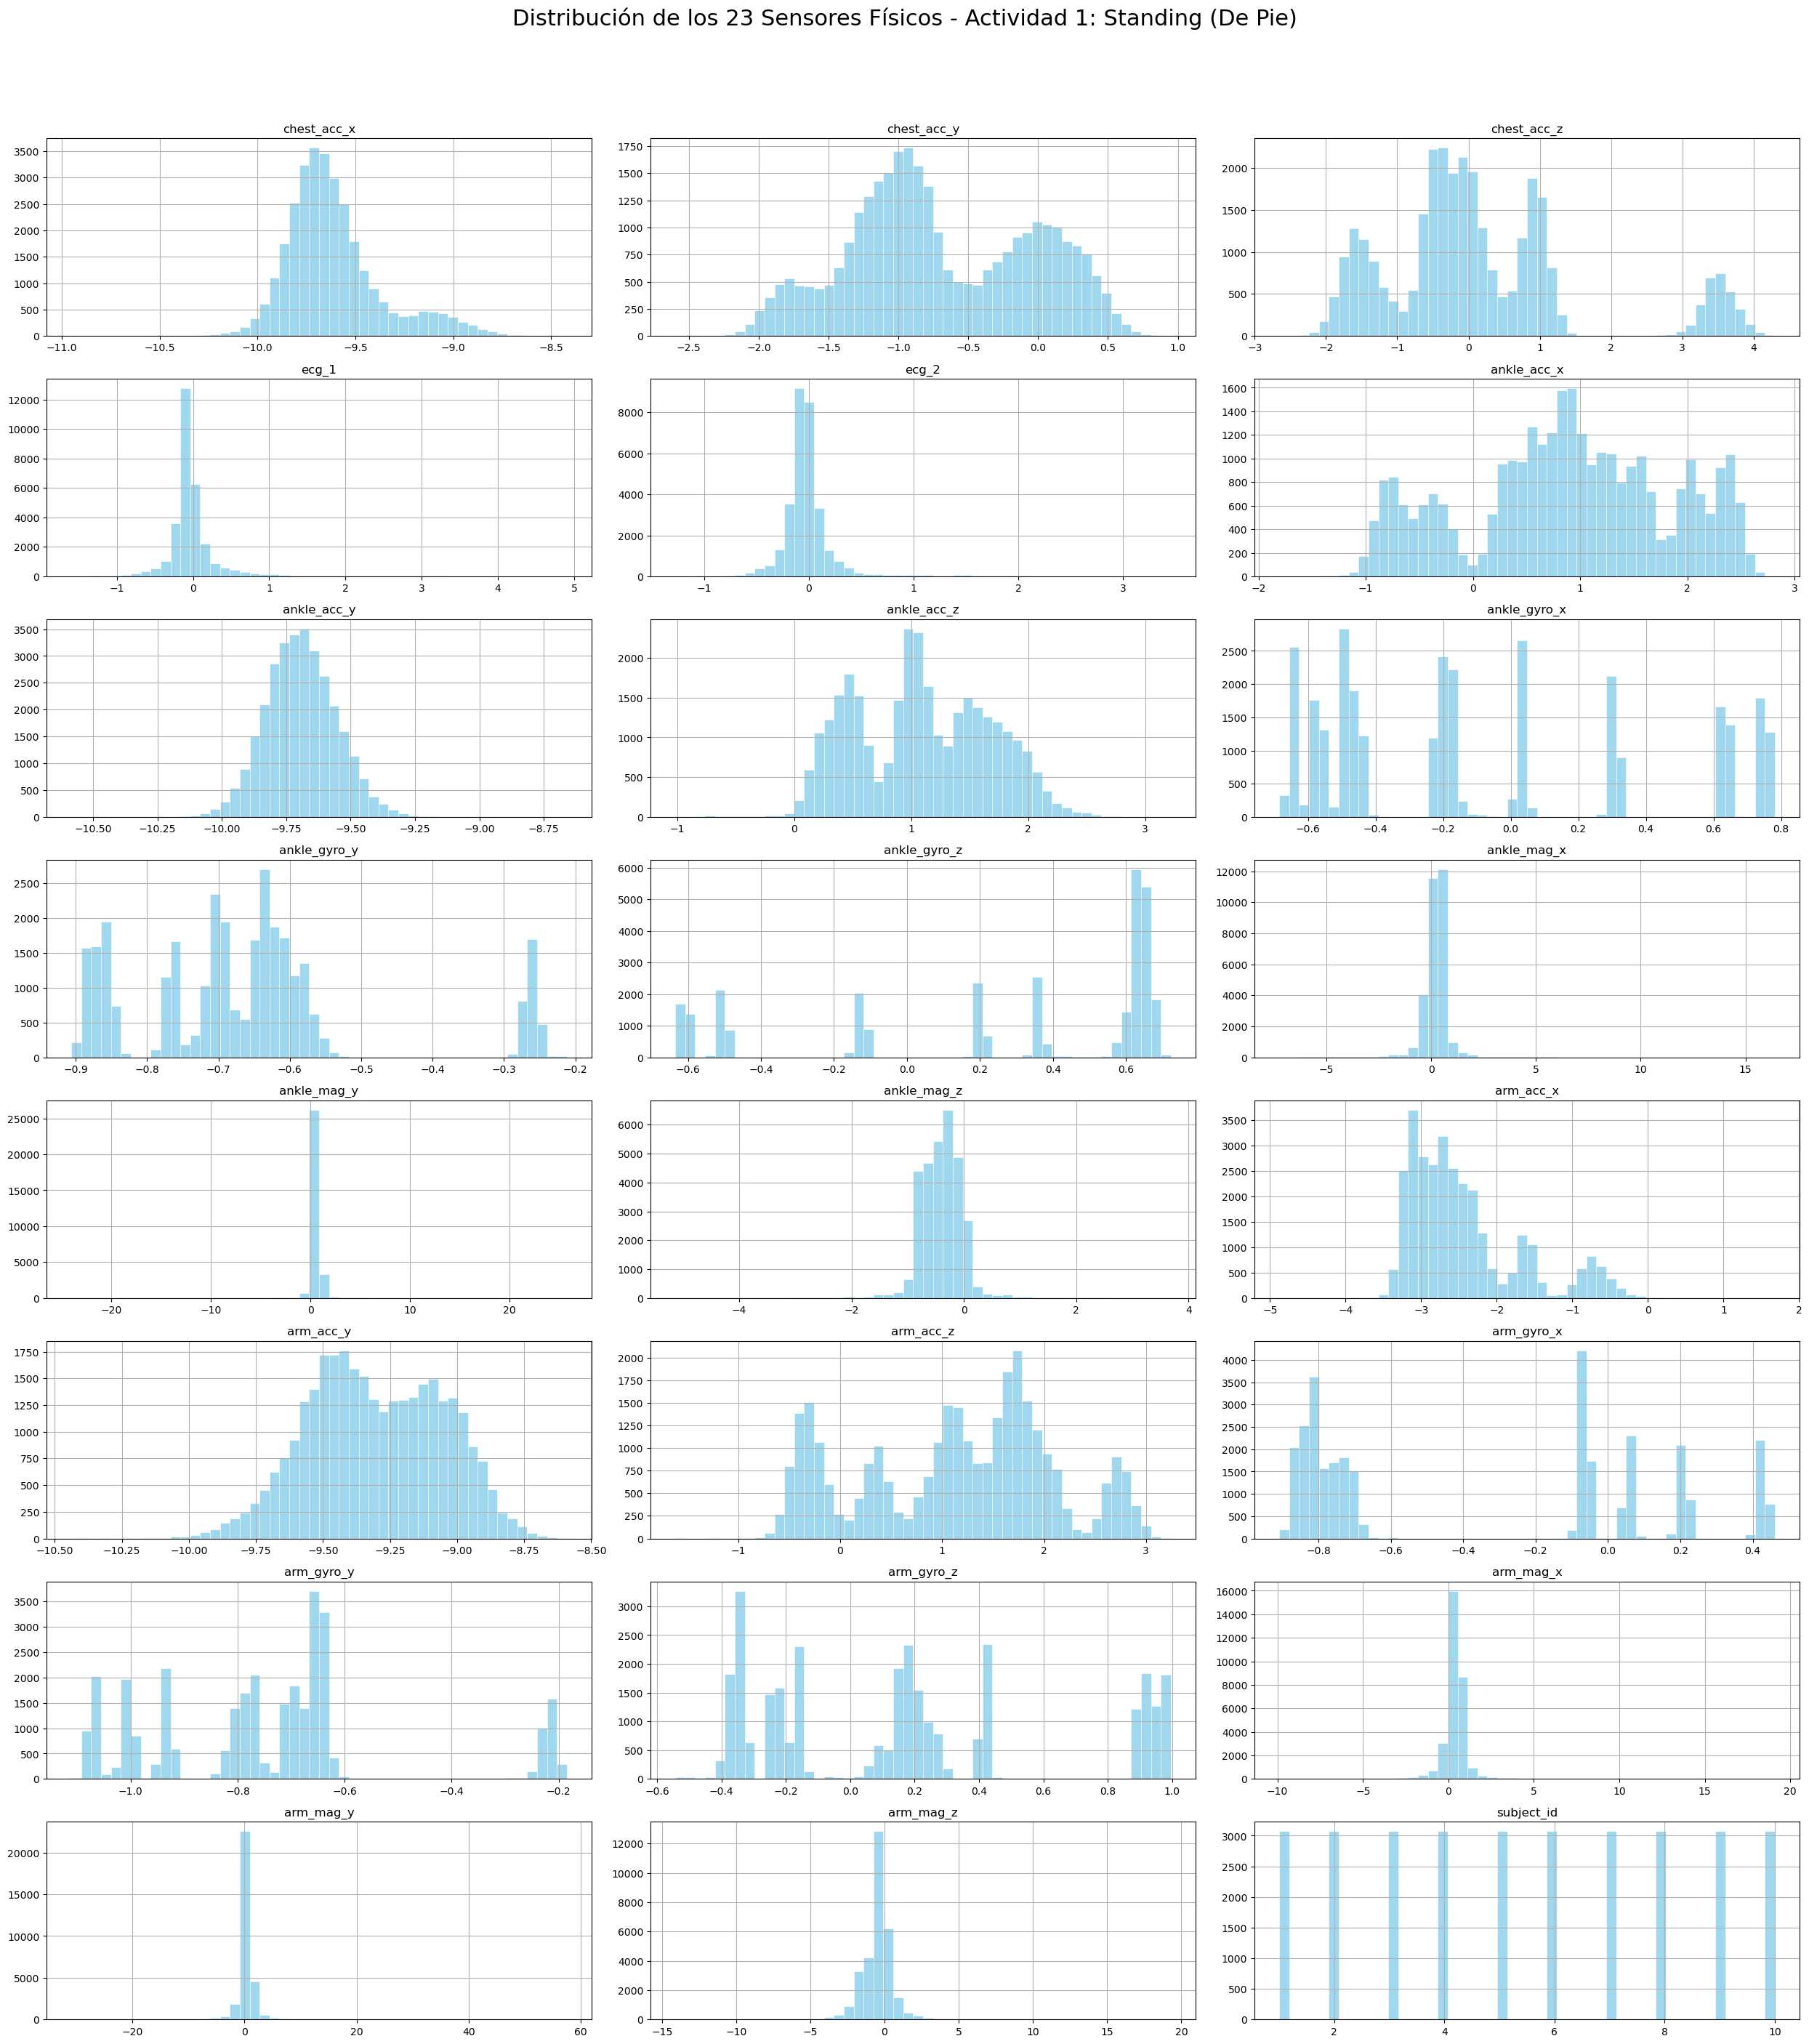

In [40]:
## Filtramos para mostrar actividad 2 (de pie)
actividad_standing = MHEALTHDATASET[MHEALTHDATASET['activity_label'] == 1]

# Le quitamos las etiquetas
sensores_standing = actividad_standing.drop(columns=['activity_label'])

sensores_standing.hist(
    bins=50, 
    layout=(15,3),
    figsize=(25, 50), 
    color='skyblue', 
    edgecolor='white', 
    linewidth=0.5,
    alpha=0.8
)

plt.suptitle('Distribución de los 23 Sensores Físicos - Actividad 1: Standing (De Pie)', fontsize=22, y=1.02)
plt.tight_layout()

plt.show

In [47]:

outliers_info = []

for col in sensores_standing.select_dtypes(include="number").columns:
    
    Q1 = sensores_standing[col].quantile(0.25)
    Q3 = sensores_standing[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    mask_outliers = (sensores_standing[col] < lower) | (sensores_standing[col] > upper)
    
    total_outliers = mask_outliers.sum()
    percentage = mask_outliers.mean() * 100
    
    outliers_info.append({
        "Sensor": col,
        "Total_Outliers": total_outliers,
        "Porcentaje_Outliers (%)": round(percentage, 2)
    })

outliers_df = pd.DataFrame(outliers_info)

outliers_df

,Sensor,Total_Outliers,Porcentaje_Outliers (%)
0,chest_acc_x,2273,7.40
1,chest_acc_y,0,0.00
2,chest_acc_z,3023,9.84
3,ecg_1,4258,13.86
4,ecg_2,3147,10.24
5,ankle_acc_x,4,0.01
6,ankle_acc_y,245,0.80
7,ankle_acc_z,6,0.02
8,ankle_gyro_x,0,0.00
9,ankle_gyro_y,3072,10.00


8. Genera la gráfica de densidad para la distribución de los atributos de cada base de datos.

<function matplotlib.pyplot.show(close=None, block=None)>

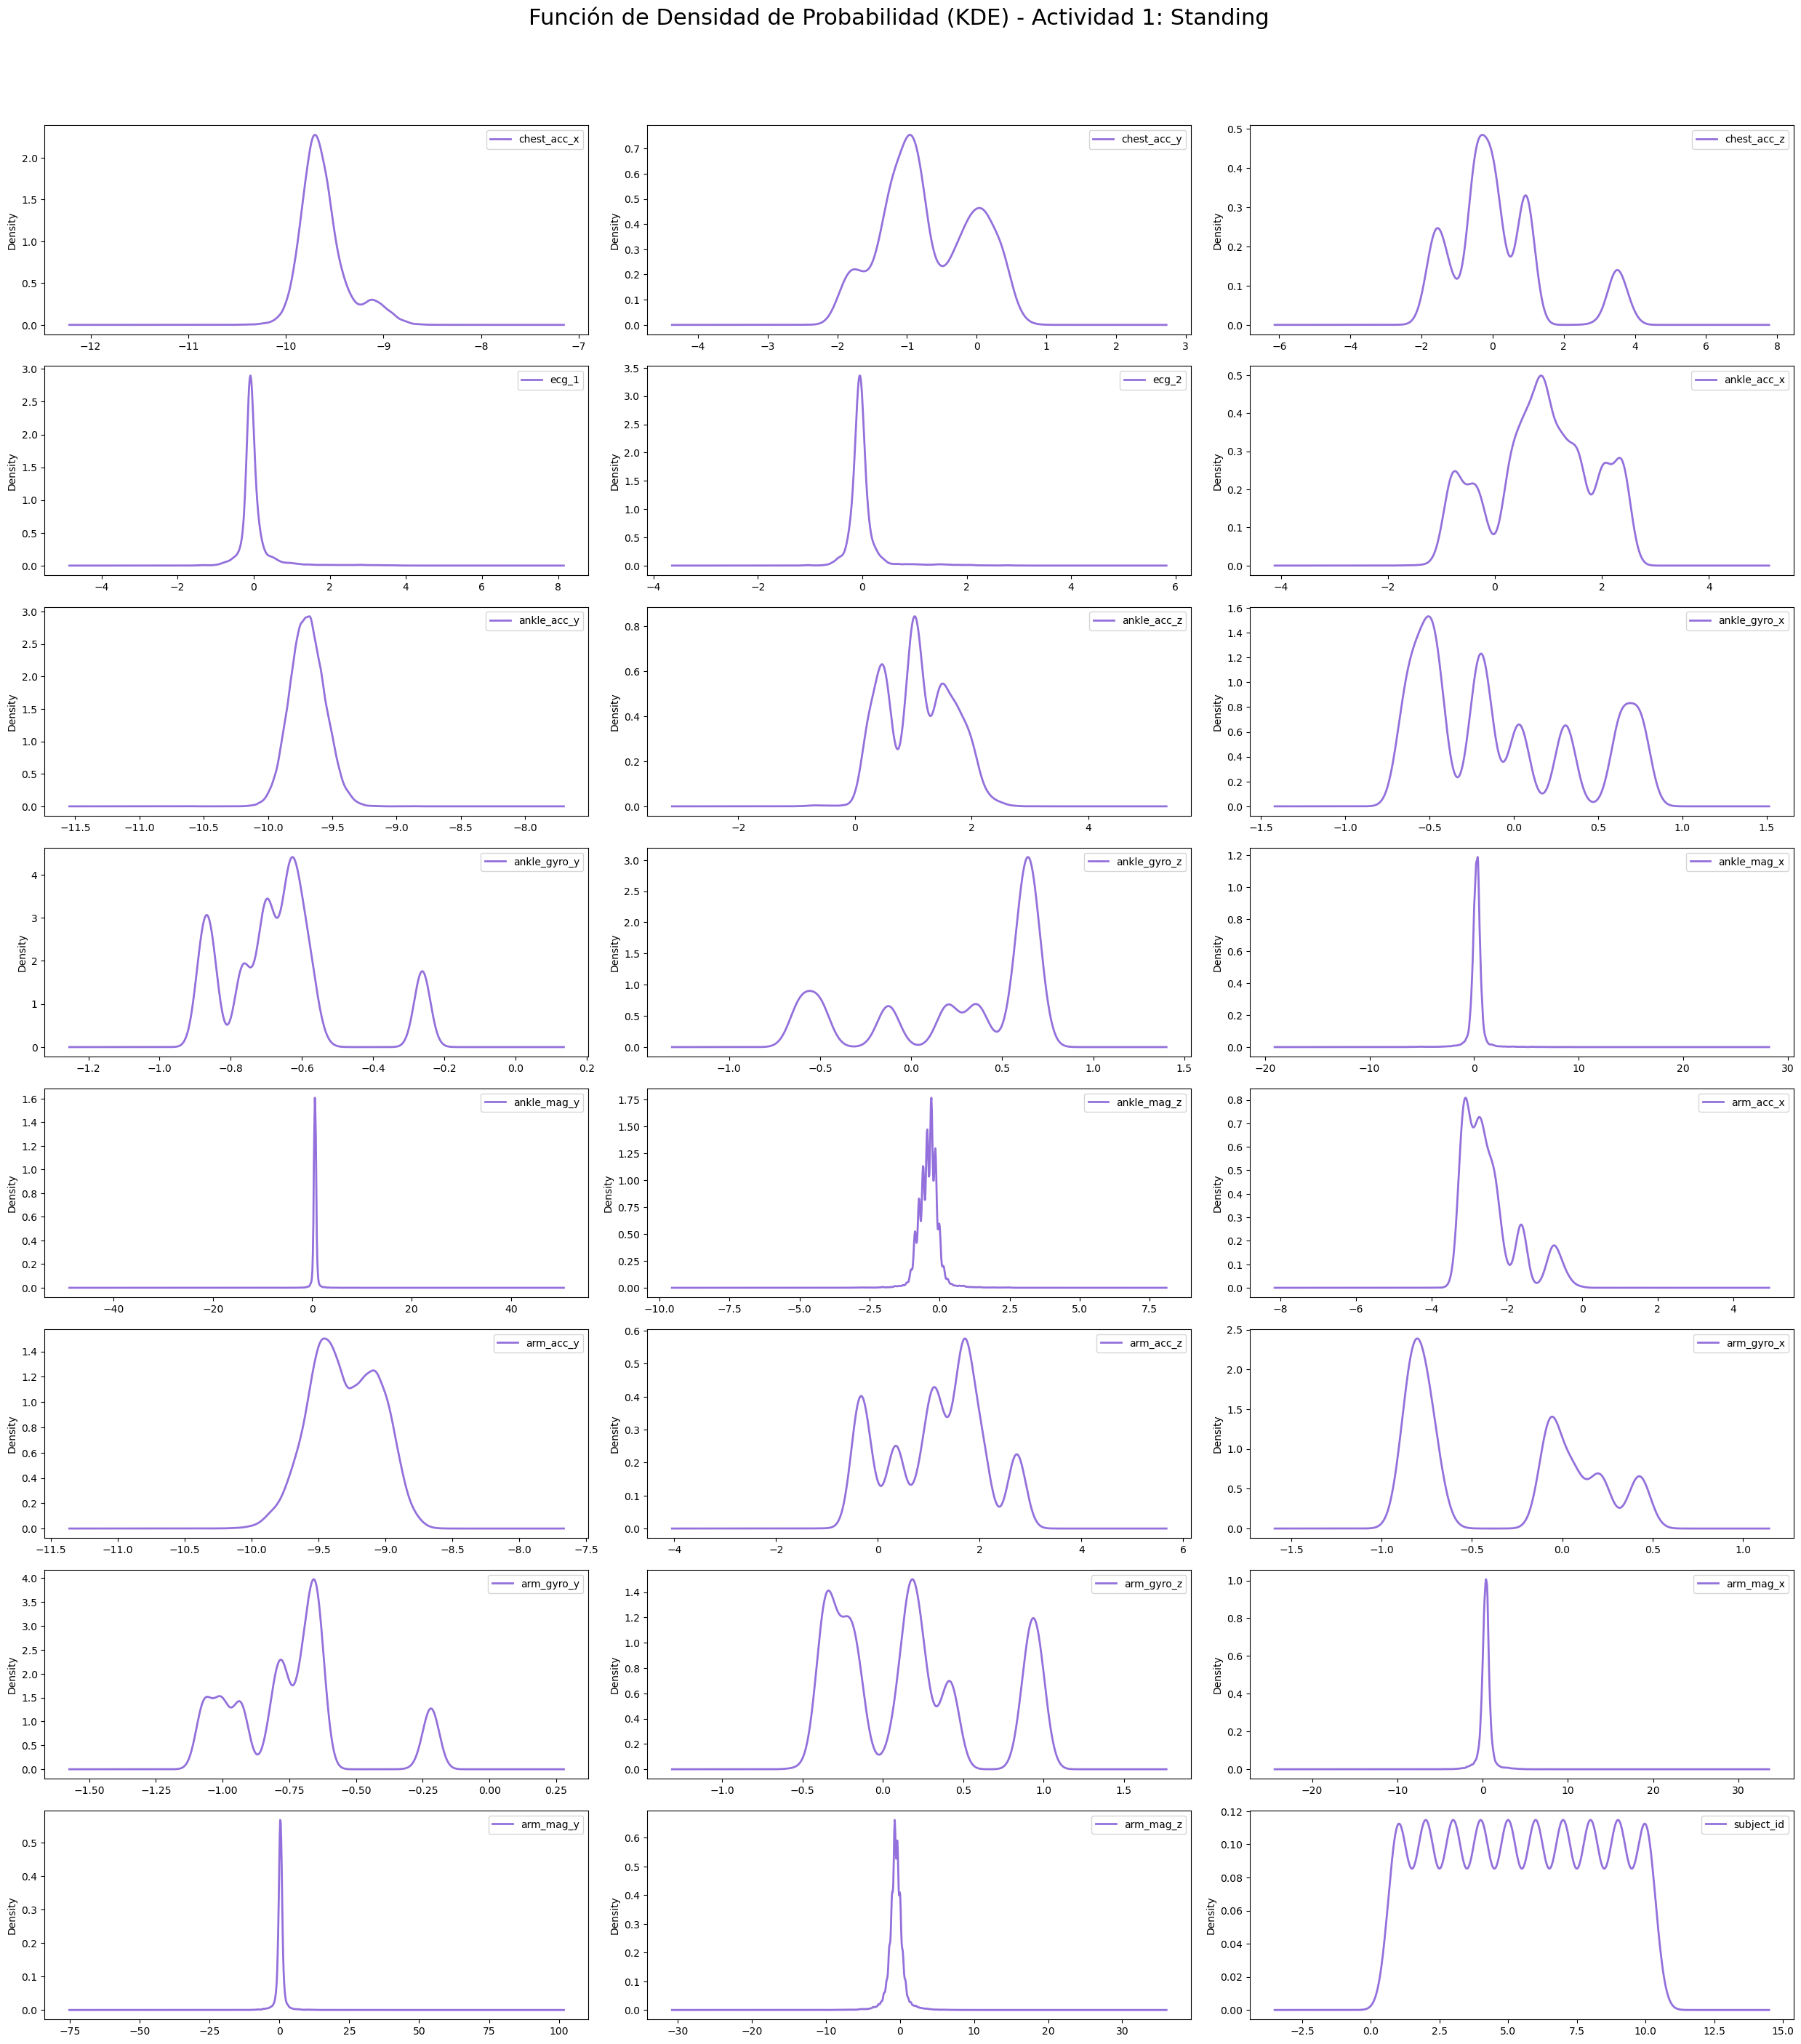

In [41]:
sensores_standing.plot(
    kind='density', 
    subplots=True, 
    layout=(15, 3),  
    figsize=(25, 50),
    sharex=False,     
    color='mediumpurple', 
    linewidth=2
)

plt.suptitle('Función de Densidad de Probabilidad (KDE) - Actividad 1: Standing', fontsize=22, y=1.02)
plt.tight_layout()

plt.show

9. Genera la gráfica de cajas y bigotes para la distribución de los atributos de cada base de datos.

<function matplotlib.pyplot.show(close=None, block=None)>

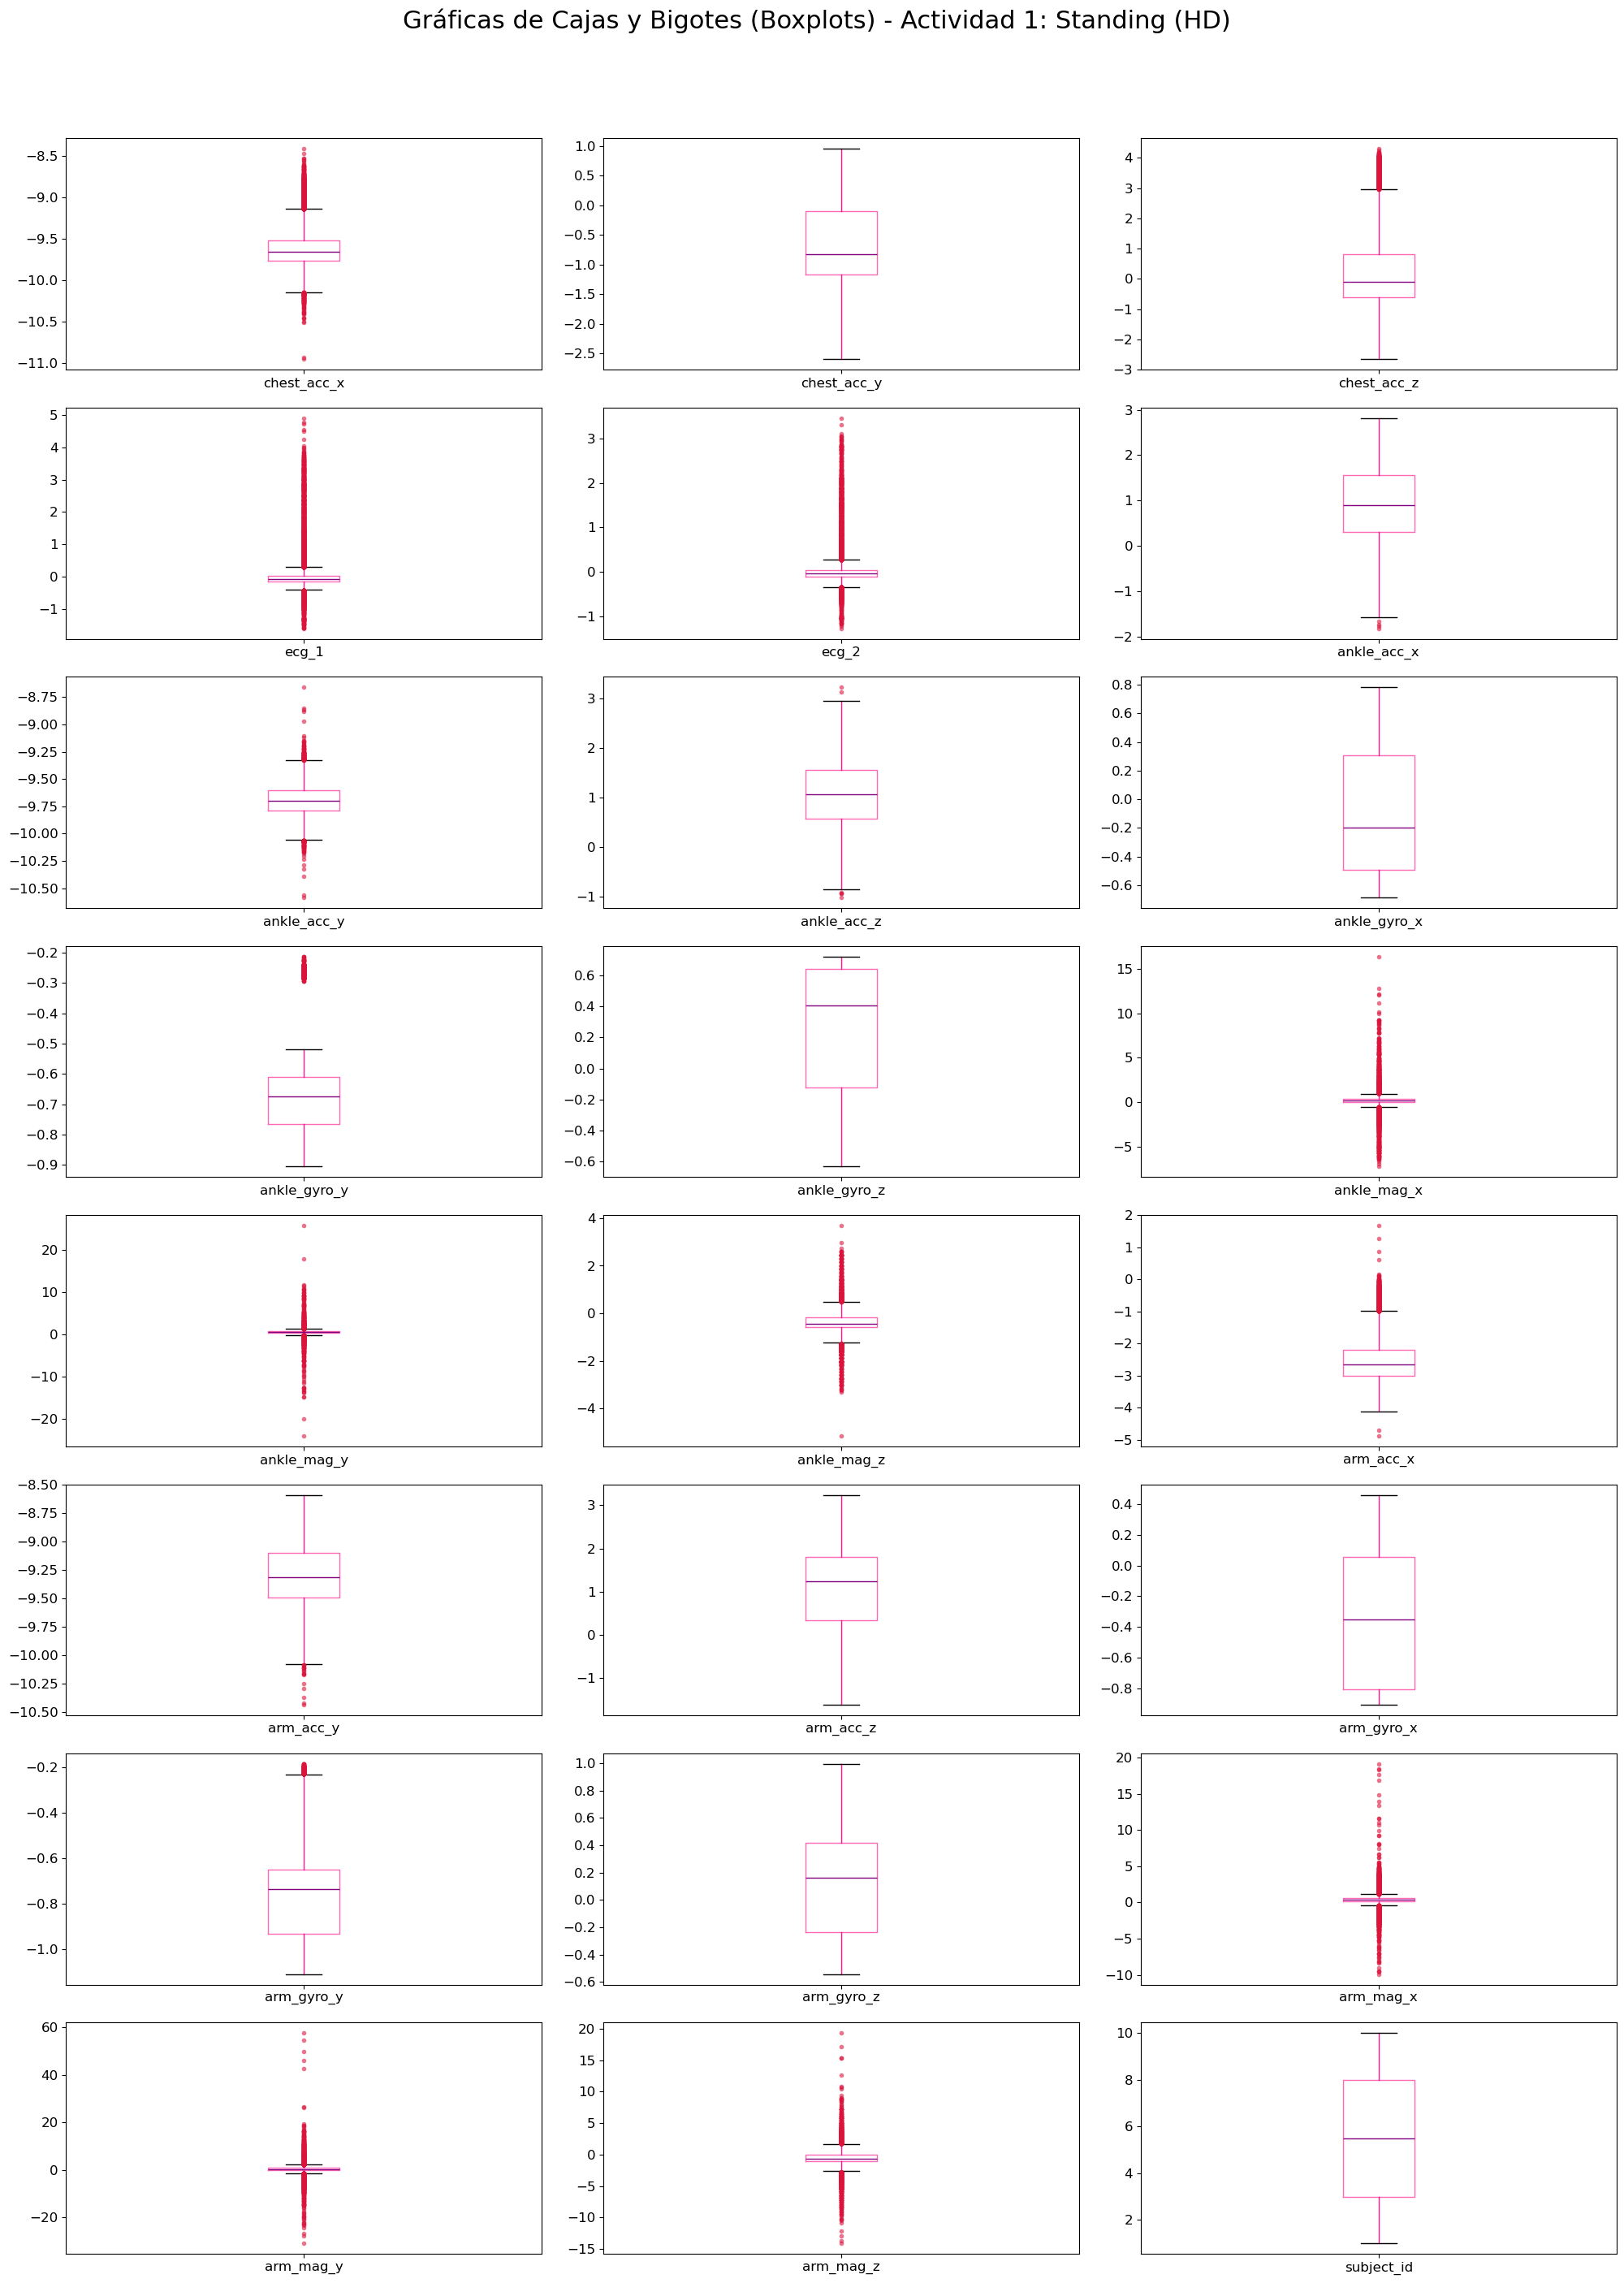

In [42]:
color_props = dict(boxes='hotpink', whiskers='deeppink', medians='purple', caps='black')
puntitos_props = dict(marker='o', markerfacecolor='crimson', markersize=4, alpha=0.6, markeredgecolor='none')

# Dibujamos el mosaico
sensores_standing.plot(
    kind='box', 
    subplots=True, 
    layout=(15, 3),  
    figsize=(20, 50), 
    color=color_props,
    flierprops=puntitos_props,
    fontsize=12      
)


plt.suptitle('Gráficas de Cajas y Bigotes (Boxplots) - Actividad 1: Standing (HD)', fontsize=22, y=1.02)
plt.tight_layout()

plt.show

10. Genera la matriz de correlación de los atributos para cada una de las bases de datos.

<function matplotlib.pyplot.show(close=None, block=None)>

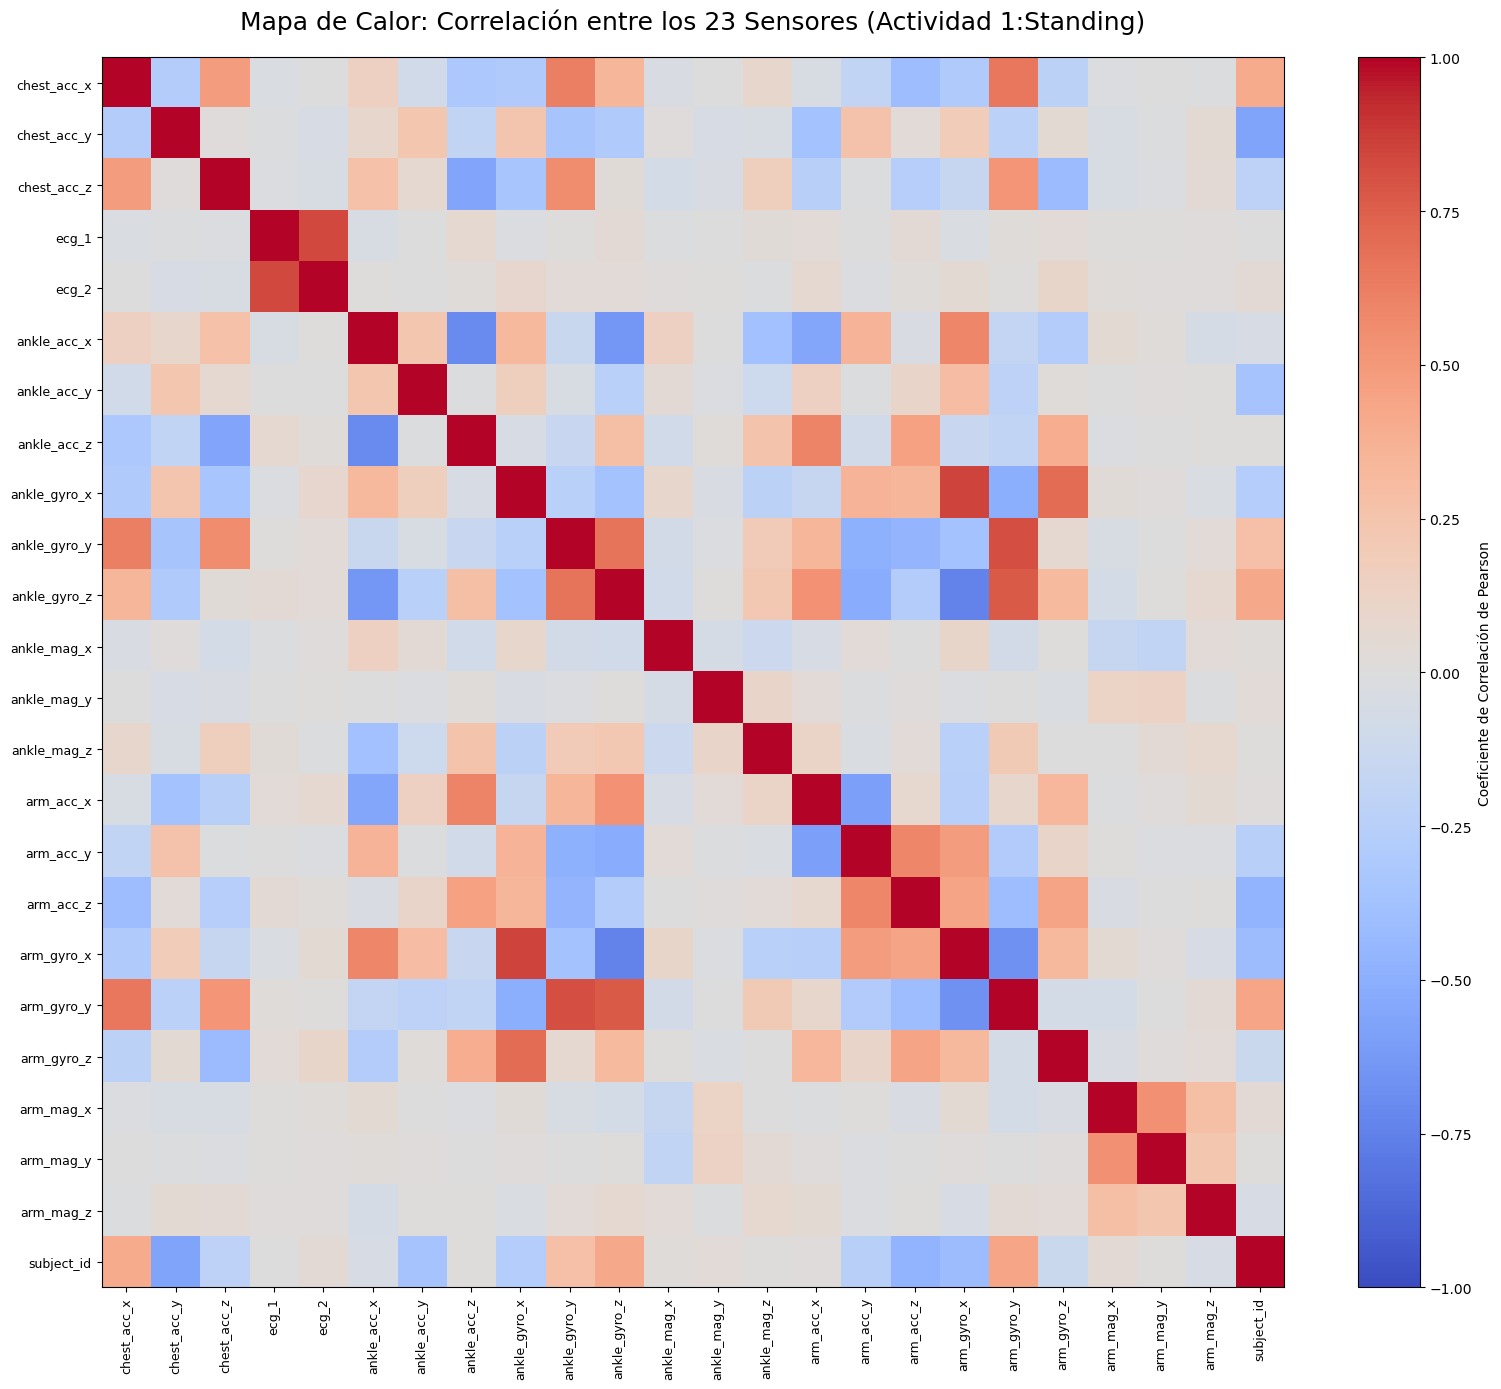

In [43]:
# Calculamos la matriz de correlación de Pearson
matriz_correlacion = sensores_standing.corr()

# Dibujamos el Mapa de Calor
plt.figure(figsize=(16, 14))

# Usamos imshow para dibujar la cuadrícula, coolwarm da rojo a los +1 y azul a los -1
imagen = plt.imshow(matriz_correlacion, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

# Agregamos la barra de colores al lado
plt.colorbar(imagen, label='Coeficiente de Correlación de Pearson')
plt.title('Mapa de Calor: Correlación entre los 23 Sensores (Actividad 1:Standing)', fontsize=18, pad=20)

# Ponemos los nombres de las 45 columnas en los bordes
posiciones = np.arange(len(sensores_fisicos.columns))
plt.xticks(posiciones, sensores_fisicos.columns, rotation=90, fontsize=9)
plt.yticks(posiciones, sensores_fisicos.columns, fontsize=9)

plt.grid(False) 
plt.tight_layout()

plt.show

11. Genera la matriz de dispersión de los atributos para cada base de datos.

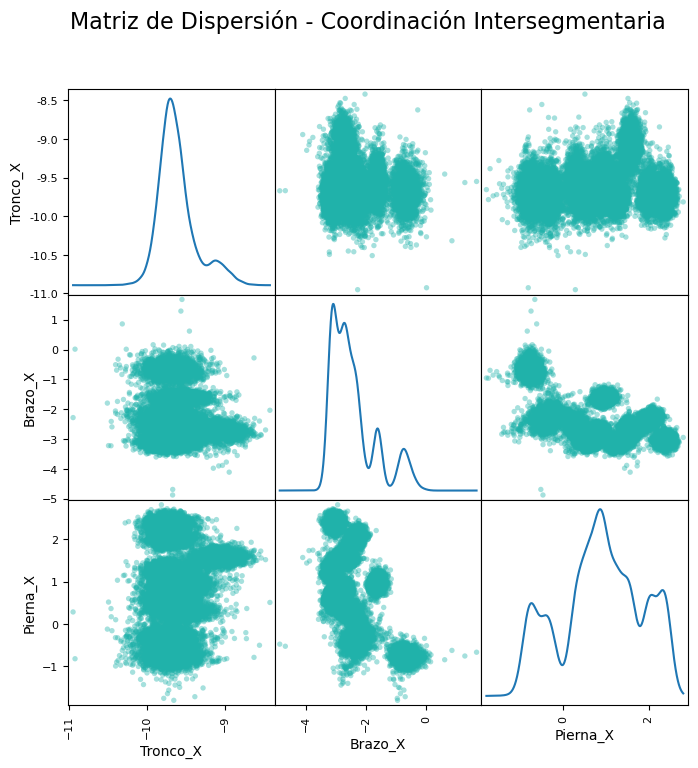

In [45]:
# Selección estratégica: un eje X por segmento corporal
sensores_estrategicos = [
    "chest_acc_x",   # Tronco
    "arm_acc_x",     # Brazo derecho
    "ankle_acc_x"    # Pierna
]

datos_scatter = sensores_standing[sensores_estrategicos].copy()


datos_scatter.columns = [
    "Tronco_X",
    "Brazo_X",
    "Pierna_X"
]

pd.plotting.scatter_matrix(
    datos_scatter,
    alpha=0.4,
    figsize=(8, 8),
    diagonal='kde',
    color='lightseagreen',
    marker='o',
    s=15
)

plt.suptitle(
    'Matriz de Dispersión - Coordinación Intersegmentaria',
    fontsize=16
)

plt.show()

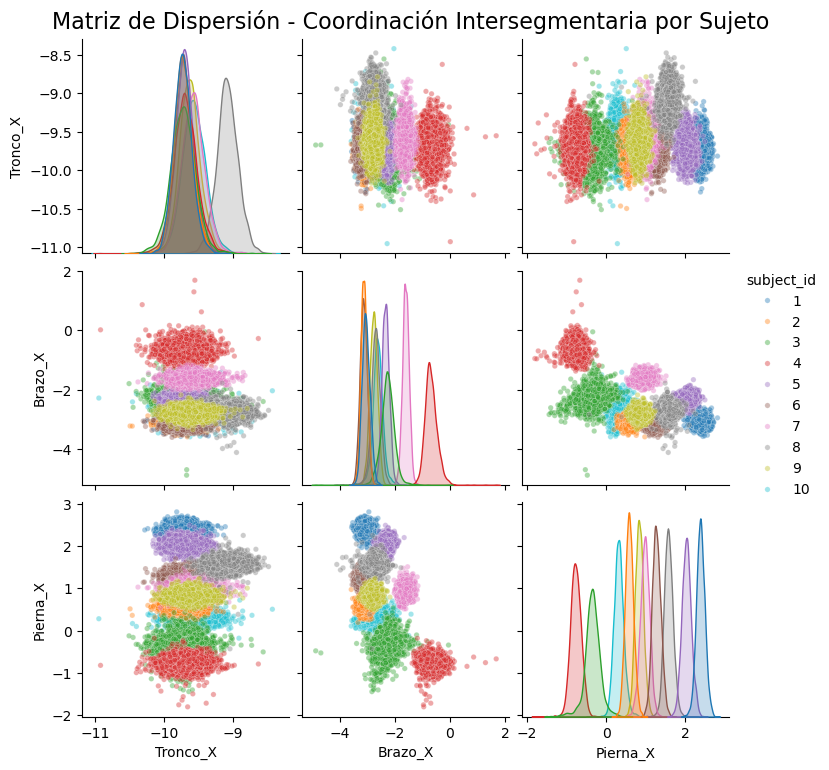

In [46]:
# Selección estratégica
sensores_estrategicos = [
    "chest_acc_x",   # Tronco
    "arm_acc_x",     # Brazo derecho
    "ankle_acc_x"    # Pierna
]

datos_scatter = sensores_standing[sensores_estrategicos + ["subject_id"]].copy()

datos_scatter.columns = [
    "Tronco_X",
    "Brazo_X",
    "Pierna_X",
    "subject_id"
]

# Convertir a categoría (importante para que seaborn lo trate como grupo)
datos_scatter["subject_id"] = datos_scatter["subject_id"].astype("category")

# Pairplot con color por sujeto
sns.pairplot(
    datos_scatter,
    vars=["Tronco_X", "Brazo_X", "Pierna_X"],
    hue="subject_id",
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "s": 15}
)

plt.suptitle(
    'Matriz de Dispersión - Coordinación Intersegmentaria por Sujeto',
    y=1.02,
    fontsize=16
)

plt.show()

In [48]:
from sklearn.preprocessing import StandardScaler

# Separar variables
X = MHEALTHDATASET.drop(columns=["activity_label", "subject_id"])
y = MHEALTHDATASET["activity_label"]
subject_ids = MHEALTHDATASET["subject_id"]

# Crear scaler
scaler = StandardScaler()

# Ajustar y transformar
X_scaled = scaler.fit_transform(X)

# Convertir nuevamente a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Volver a unir todo
MHEALTHDATASET_scaled = pd.concat(
    [X_scaled, y.reset_index(drop=True), subject_ids.reset_index(drop=True)],
    axis=1
)

MHEALTHDATASET_scaled.head()

,chest_acc_x,chest_acc_y,chest_acc_z,ecg_1,ecg_2,ankle_acc_x,ankle_acc_y,ankle_acc_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,arm_acc_x,arm_acc_y,arm_acc_z,arm_gyro_x,arm_gyro_y,arm_gyro_z,arm_mag_x,arm_mag_y,arm_mag_z,activity_label,subject_id
0,-0.318024,0.104711,0.378153,0.012468,0.011956,0.180505,-0.000916,0.290303,0.214771,-0.631339,-0.967156,-0.013319,0.010346,0.065390,-1.036297,0.213182,-0.569101,-0.327682,-0.978967,-0.411337,-0.094474,-0.069508,0.004830,0,1
1,-0.325508,0.345048,0.399934,0.012468,0.029230,0.233478,0.044322,0.300028,0.176993,-0.626038,-0.959969,-0.010630,0.014599,0.081415,-1.031594,0.258044,-0.611450,-0.327682,-0.978967,-0.411337,-0.087472,-0.047751,0.009969,0,1
2,-0.279204,0.185068,0.417824,0.029289,0.058021,0.238966,0.030081,0.299523,0.176993,-0.626038,-0.959969,-0.013385,0.023227,0.073245,-1.005983,0.265443,-0.546410,-0.327682,-0.978967,-0.411337,-0.067015,-0.026315,0.004833,0,1
3,-0.276873,0.200201,0.362681,0.113398,0.167428,0.179590,0.062997,0.275571,0.176993,-0.626038,-0.959969,-0.007804,0.023143,0.081004,-1.031678,0.258652,-0.522729,-0.342539,-0.975187,-0.426612,-0.046758,-0.021155,-0.000227,0,1
4,-0.289707,0.242124,0.382610,0.304036,0.288343,0.241240,0.072874,0.304988,0.176993,-0.626038,-0.959969,-0.013388,0.006053,0.073660,-1.046982,0.288248,-0.512470,-0.342539,-0.975187,-0.426612,-0.026505,-0.016103,-0.010477,0,1
